In [63]:
%%HTML

<link rel="stylesheet" href="rise.css"/>

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from geoana.em import fdem
from matplotlib.patches import Arc
from ipywidgets import interact, FloatSlider, FloatLogSlider
from em_utilities import AmpPhaseInteract, interactfem3loop


plt.rcParams['figure.figsize'] = [6.4, 4.2]
plt.rcParams['figure.dpi'] = 150

In [33]:
def do_plane_plot(polar=False):

    a = 3
    b = 2
    plt.figure()

    if not polar:
        plt.stem(a,b, linefmt='r--')
        plt.stem(b,a, linefmt='r--', orientation='horizontal')
        annot_text = f'z={a}+{b}i'
    else:
        plt.plot([0, a], [0, b], linestyle='--', color='r')
        ax = plt.gca()
        theta = np.angle(a + 1j * b, deg=True)
        arc = Arc([0,0], 2, 2, theta1=0, theta2=theta, linestyle='--', color='r', linewidth=1.5)
        ax.add_patch(arc)

        #9 + 4 = 13
        annot_text = rf"z=$\sqrt{{13}} e^{{i {theta:.2f}}}$"
    #print(annot_text)
    plt.annotate(annot_text, [a,b], [a+0.2, b+0.2])
    plt.scatter(a,b, color='C0')
    plt.title("The complex plane")
    plt.xlabel('real')
    plt.ylabel('imaginary')
    plt.grid();
    plt.axis('scaled')
    plt.xlim([0, 5])
    plt.ylim([0, 5])

# Frequency Domain Electromagnetics (FDEM/FEM)
### Fundamentals and Instrumentations


Date: January 22, 2025

Topics:
* Frequency to Time (again)
* Frequency domain EM physics
* Low induction number systems

## Transient and Harmonic Signals


<div class="row">
<div class="column">

We have seen this:

![Transient Pulse](resources/transient_waveform.png)
</div>
<div class="column">

What happens when we have a harmonic source?

![Harmonic](resources/harmonic_waveform.png)
</div>
</div>

### Complex numbers
(an aside)

Recall a complex number:
$$
z = a + i b
$$
has a real part $a$ and imaginary part $b$

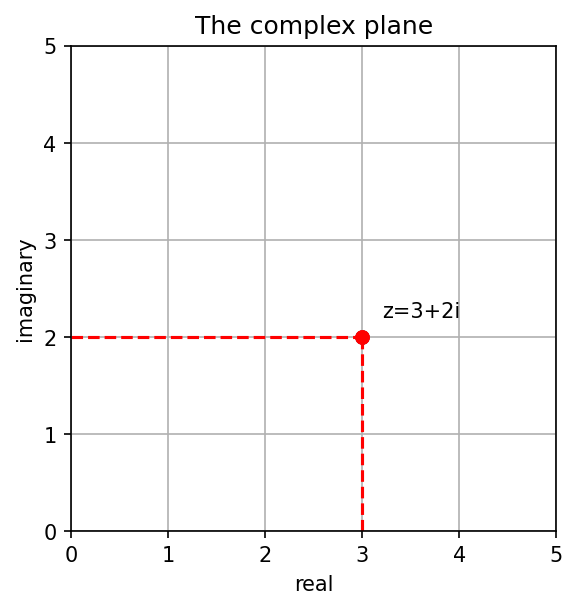

In [64]:
do_plane_plot()

Alternatively in "*Polar*" form:
$$
z = r e^{i\phi}
$$
with an amplitude of $r$ and phase $\phi$

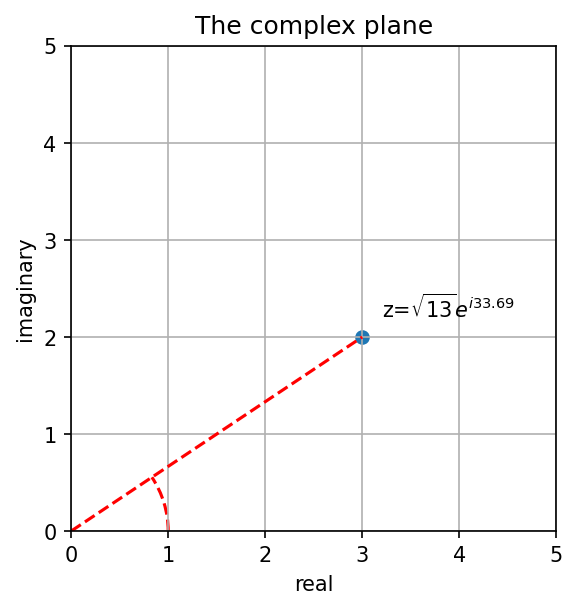

In [35]:
do_plane_plot(polar=True)

### Why so complicated?
Why do we use complex numbers?

* Useful to describe a wave like signal as a combination of sin and cos.

$$
f(\omega t) = I\cos(\omega t) + Q\sin(\omega t)
$$

* The real part describes the in-phase $Re(z) = I$
* The imaginary part describes the quadrature (out-of-phase) $Im(z) = Q$

> **Basically** Complex numbers are just a convenient way to describe a wave

In [36]:
from IPython.display import display

In [137]:
%matplotlib widget
box = AmpPhaseInteract(figsize=(6, 2)).display()
display(box)

AppLayout(children=(FloatLogSlider(value=0.1, layout=Layout(grid_area='footer'), max=2.0, min=-2.0), Canvas(la…

In [141]:
%matplotlib inline
plt.close('all')

### Faraday's law in Frequency domain:

<div class="row">
  <div class="column">

$$\nabla \times \vec{E} = -\frac{\partial \vec{B}}{\partial t} = - i\omega \vec{B}$$

* Time dependant magnetic fields produce electric fields
* Lenz's Law (The negative sign in Faraday's Law):
    * Nature still **opposes** changes in the magnetic field
    * Induced currents will attempt to re-create the magnetic field as it was
* How do the *Phases* of $\vec{E}$ and $\vec{B}$ compare now?
  
  </div>
  <div class="column">

![Amperes](resources/1-faraday-loop.png "B field due to a wire")

  </div>
</div>

## Three Loop system
You've likely seen this before:

<div class=center>

![3-loop](https://em.geosci.xyz/_images/Concepts_3loops_only_M.png)
</div>

### Data
<div class="row">
<div class="column">

The field measured in the Rx antenna is both primary **and** secondary fields (the Total Field)

* The primary field is strong, but not interesting
* We're only interested in the secondary fields. They're the ones that give us information about the earth

</div>
<div class="column">

![FDEMFields](resources/FDEMFields.png)

</div>
</div>

Where the ratio of secondary to primary field is given by:

$$
\frac{H_s}{H_p} = \frac{-M_{12}M_{23}}{M_{13}L}\frac{\alpha^2 + i \alpha}{1 + \alpha^2}
$$
$$\alpha = \omega \frac{L}{R}$$

* $L$ is self-inductance of loop 2
* $R$ is resistance of loop 2
* $M_{ij}$ is the mutual inductance between loops $i$ and $j$

In [61]:
def do_loop_loop():
    alpha = np.logspace(-5, 5)

    v = (alpha ** 2 + 1j * alpha)/(1 + alpha**2)

    fig, axs = plt.subplots(1, 2, figsize=(8, 3))
    ax = axs[0]
    ax.semilogx(alpha, v.real, label='real')
    ax.semilogx(alpha, v.imag, label='imag')
    ax.axvspan(1E2, 1E6, alpha=0.1)
    ax.axvspan(1E-6, 1E-2, alpha=0.1, color='C1')
    ax.annotate('high conductance\n or frequency', [2E2,0.5])
    ax.annotate('low conductance\n or frequency', [2E-5,0.5])
    ax.legend()
    ax.set_xlim([1E-5,1E5])
    ax.set_xlabel(r'$\alpha$')

    ax = axs[1]
    
    ax_p = ax.twinx()
    ax.loglog(alpha, np.abs(v), label='amplitude', color='C0')
    ax_p.semilogx(alpha, np.angle(v,deg=True), label='phase', color='C1')

    ax_p.set_ylabel('Phase', color='C1')
    ax.set_ylabel('Amplitude', color='C0')

    plt.axvspan(1E2, 1E6, alpha=0.1)
    plt.axvspan(1E-6, 1E-2, alpha=0.1, color='C1')
    plt.annotate('high conductance\n or frequency', [2E2,0.5])
    plt.annotate('low conductance\n or frequency', [2E-5,0.5])
    ax_p.spines['right'].set(color='C1')
    ax.set_xlim([1E-5,1E5])
    ax.set_xlabel(r'$\alpha$')

    plt.tight_layout()

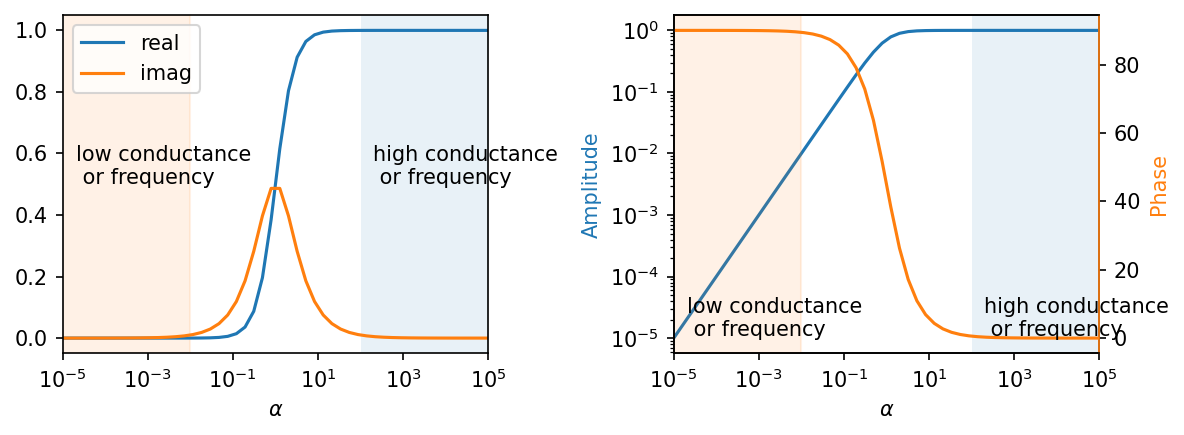

In [62]:
do_loop_loop()

In [142]:
interactfem3loop()

interactive(children=(FloatSlider(value=0.1, continuous_update=False, description='L', max=0.2, step=0.01), Fl…

### 3-loop takeaways
* Phase shift of the secondary field ($H_s$) depends on the frequency:
    * Low frequency $H_s$ is 90 degrees out of phase
    * High frequency $H_s$ is in phase
* The total field feceived signal's component that is out-of-phase with the primary signal is only due to the secondary field

## What about in the earth?

* Replace the target coil with a (layered) halfspace
* Now the whole earth is excited at the same time!

<div class=center>
    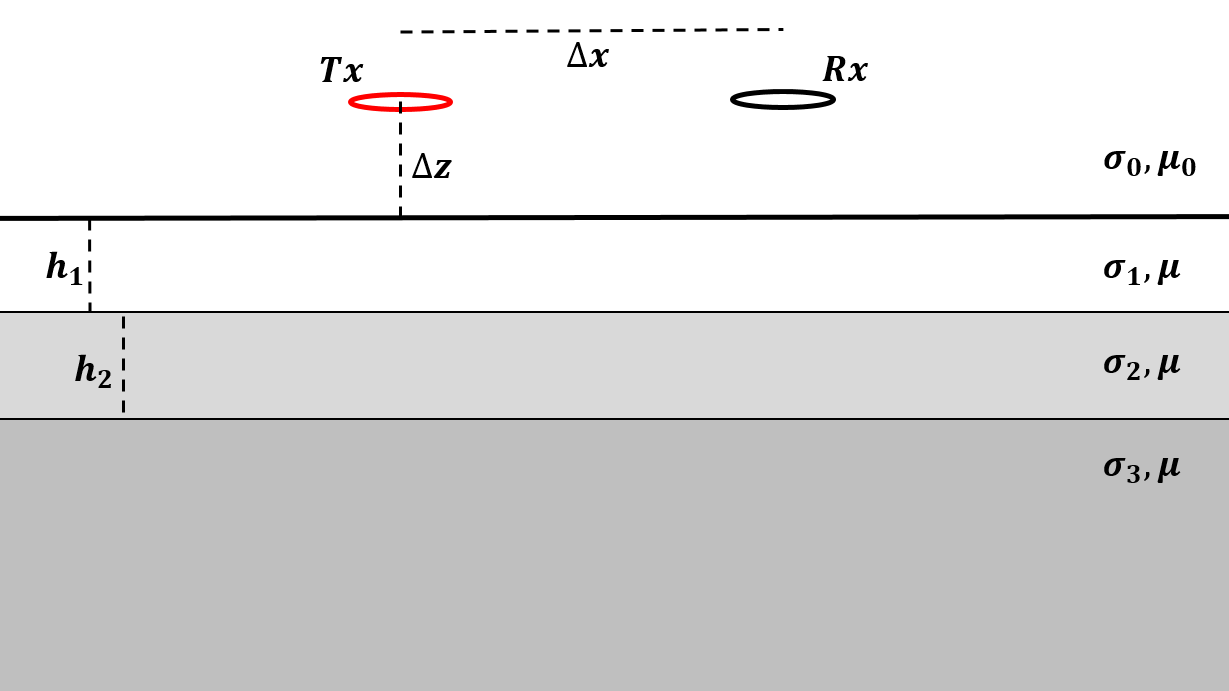
</div>


### How far does it penetrate?
<div class='row'>
<div class='column'>

* EM waves decay with depth ($d$) with amplitude proportional to 
  $$ |\vec{E}(d)| \propto e^{-k d}$$

* Skin depth is the depth at which the field's amplitude has decrease by a factor of $\frac{1}{e}$

  $$\delta = \frac{1}{k}$$

* Wavenumber ($k$) is related to angular frequency ($\omega$) and the physical properties:
  $$k = \sqrt{\omega^2 \mu \varepsilon - i \omega \mu \sigma}$$

* In the quasistatic regime this simplifies to:

  $$\delta \approx \sqrt{\frac{2}{\mu \sigma \omega}} \approx 500 \sqrt{\frac{1}{\sigma f}}$$
</div>
    
<div class='column'>

<img src="resources/wave_decay.png" style="height:100%">
</div>
</div>

### Skin depth takeaways:
* Depth EM field penetrates depends on
    * Frequency
    * Conductivity
* Higher Frequencies or Conductivites $\rightarrow$ Shallower skin depth $\rightarrow$ Shallower information
* Lower Frequencies  or Conductivites $\rightarrow$ Larger skin depths $\rightarrow$ Deeper information

FDEM vs TDEM:
* Low Frequencies $\leftrightarrow$ Late Times
* High Frequencies $\leftrightarrow$ Early Times

### Survey configurations:

You can put the transmitter and receiver loop in any configuration you want

There are a few simple configurations that are easier to interpret

In [143]:
def do_survey_plot(freq, sigma, func, offset=3.3):

    fig, axs = plt.subplots(1,2, figsize=(8, 3))
    axz, axa = axs
    axp = axa.twinx()
    for i, sig in enumerate(sigma):
        val = func(freq, sig, offset=offset)
                        
        axz.semilogx(freq, val.real, color=f'C{i}', label=rf"$\sigma$={sig}")
        axz.semilogx(freq, val.imag, color=f'C{i}', linestyle='--')

        axa.loglog(freq, np.abs(val), color=f'C{i}')
        axp.semilogx(freq, np.angle(val, deg=True), linestyle='--', color=f'C{i}')

    axz.legend()
    axz.set_xlabel('frequency (Hz)')
    axz.set_ylabel('Hs/Hp')
    axa.set_xlabel('frequency (Hz)')
    axa.set_ylabel('Amplitude')
    axp.set_ylabel('Phase')

    plt.tight_layout()

### Vertical Coplanar (VCP)
<div class="row">
<div class="column">

* Tx and Rx loops are vertical
* Tx and Rx loops are in the same plane
* Ratio of Rx field $H_{total}$ field to $H_P$ is for a separation of $\rho$:

$$\frac{H_{total}}{H_p} = \frac{2}{k^2 \rho^2} \left[3 + k^2 \rho^2 - \left(3 - 3 i k \rho - k^2 \rho^2\right)e^{-ik\rho}\right]$$

> **Connection to 3-loop**: can subtract 1 from the above equation to get
>  $$\frac{H_{total}}{H_p} - 1 = \frac{H_{total} - H_p}{H_p} = \frac{H_s}{H_p}$$

</div>
<div class="column">

![VCP](resources/VCP.png)
</div>
</div>

In [144]:
def vcp_ratio(freq, sig, offset):
    k = fdem.wavenumber(freq, sig)
    kr = k * offset
    vcp_ratio = 2 / (kr**2) * (3 + kr**2 - (3 + 3j * kr - kr**2)*np.exp(-1j * kr))
    return vcp_ratio - 1

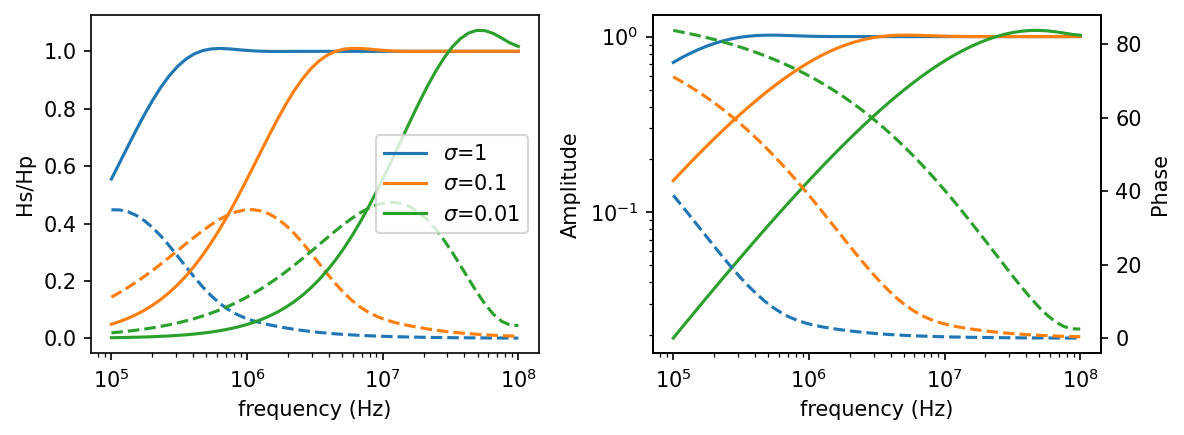

In [145]:
do_survey_plot(np.logspace(5, 8), [1, 0.1, 0.01], vcp_ratio)

### Horizontal Coplanar (HCP)
<div class="row">
<div class="column">

* Tx and Rx loops are flat
* Tx and Rx loops are in the same plane
* Ratio of Rx field $H_{total}$ field to $H_P$ is for a separation of $\rho$:

$$\frac{H_{total}}{H_p} = \frac{2}{k^2 \rho^2} \left[-9 + \left(9 + 9 i k \rho - 4 k^2 \rho^2 - i k^3 \rho^3\right)e^{-ik\rho}\right]$$

</div>
<div class="column">

![HCP](resources/HCP.png)
</div>
</div>

In [146]:
def hcp_ratio(freq, sig, offset):
    k = fdem.wavenumber(freq, sig)
    kr = k * offset
    vcp_ratio = 2 / (kr**2) * (-9 + (9 + 9j * kr - 4*kr**2 - 1j*kr**3)*np.exp(-1j * kr))
    return vcp_ratio - 1

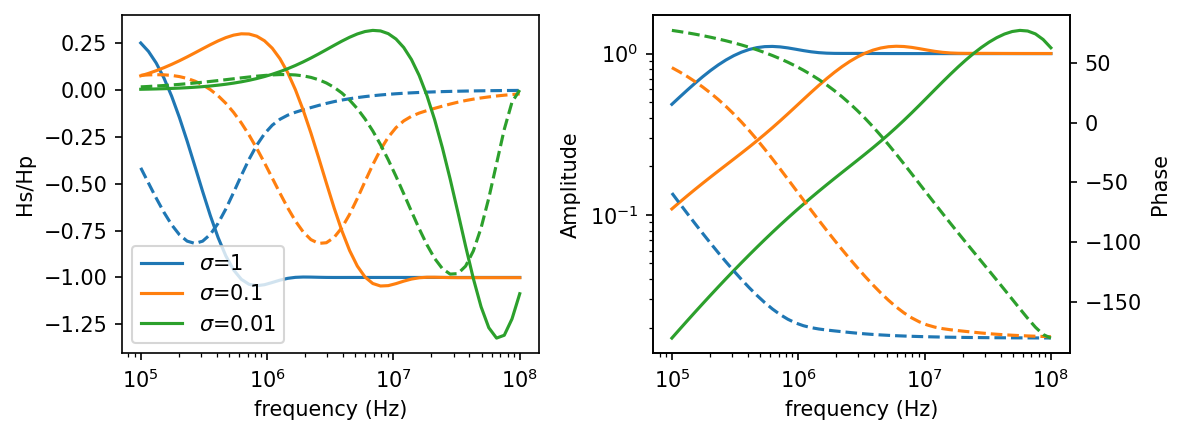

In [147]:
do_survey_plot(np.logspace(5, 8), [1, 0.1, 0.01], hcp_ratio)

### Vertical Coaxial

<div class="row">
<div class="column">

* Tx and Rx loops are vertical
* Tx and Rx centers and normals are aligned
* Ratio of Rx field $H_{total}$ field to $H_P$ is for a separation of $\rho$:

$$\frac{H_{total}}{H_p} = \frac{1}{k^2 \rho^2} \left[12 + 2k^2 \rho^2 - \left(12 + 12 i k \rho - 5 k^2 \rho^2 - i k^3 \rho^3\right)e^{-ik\rho}\right]$$

</div>
<div class="column">

![VCA](resources/VCA.png)
</div>
</div>

In [148]:
def vca_ratio(freq, sig, offset):
    k = fdem.wavenumber(freq, sig)
    kr = k * offset
    vcp_ratio = 1 / (kr**2) * (12 + 2*kr**2 - (12 + 12j * kr - 5*kr**2 - 1j*kr**3)*np.exp(-1j * kr))
    return vcp_ratio - 1

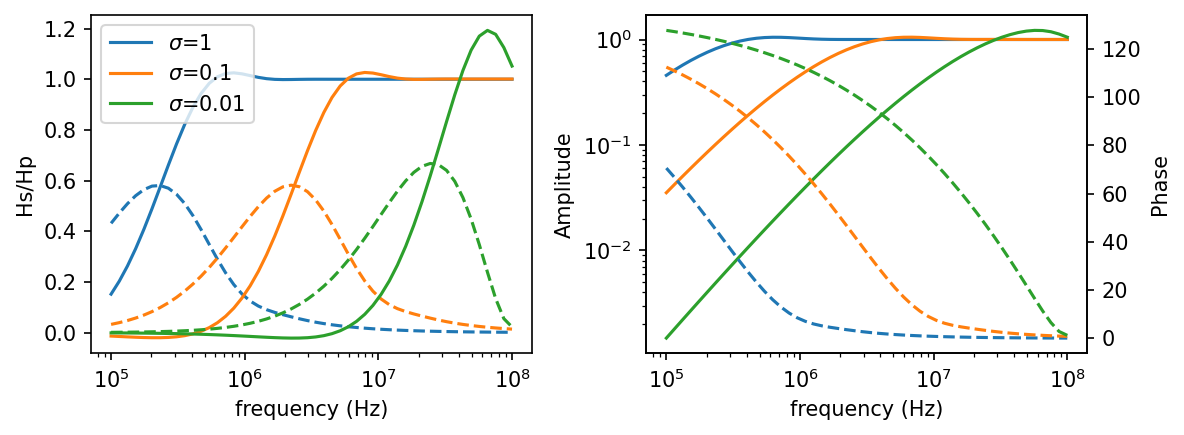

In [149]:
do_survey_plot(np.logspace(5, 8), [1, 0.1, 0.01], vca_ratio)

## Exampels of FDEM systems

### "Ground Conductivity Meters"

#### Geonics EM31

<div class="row">
<div class="column">

* 9.8 kHz Frequency
* 3.66 m separation
* VCP or HCP (By literally rotating the equipment)

![em31-1](resources/3-EM31_1.png)


![em31-2](resources/3-EM31_2.png)
</div>
<div class="column">

![em31-3](resources/3-EM31_3.jpg)


![em31-4](resources/3-EM31_4.png)
</div>
</div>

#### Geonics EM34
<div class="row">
<div class="column">

* sep = 10m, f=6.4 kHz

<img src="resources/3-EM34-Geom.png" style="width:25%">

* sep = 20m, f=1.6 kHz

<img src="resources/3-EM34-Geom2.png" style="width:50%">

* sep = 40m, f=0.4 kHz

<img src="resources/3-EM34-Geom3.png" style="width:100%">

</div>
<div class="column">

![em31-3](resources/3-EM34_1.jpg)


![em31-4](resources/3-EM34_2.jpg)
</div>
</div>

#### GEM-2 "The Ski"

<div class="row">
<div class="column">

* Multiple frequency waveform

![em31-3](resources/3-GEM2-waveform.jpg)


</div>
<div class="column">

![em31-3](resources/3-GEM2-1.png)


![em31-4](resources/3-GEM2-2.png)
</div>
</div>

### GEM3 (Basically a metal detector)
* Cocentric Tx-Rx
* Multiple frequencies

![em31-3](resources/3-GEM3.png)

And many more...

### Airborne Systems

#### Resolve

![Resolve1](resources/3-Resolve-4.png)
<div class="row">
<div class="column">

![Resolve1](resources/3-Resolve-1.png)
</div>
<div class="column">

![Resolve2](resources/3-Resolve-2.png)
![Resolve1](resources/3-Resolve-3.png)
</div>
</div>


